# 텐서플로우 데이터셋 활용 - 멀티클래스 꽃 분류기

회고: 
- DL톤 진행 시 많이 헷갈렸던 부분- 시각화,증강,모델 훈련의 단계마다 인풋 데이터 shape 이 어떻게 바뀌는지 완벽히 이해하지 못했는데 차근차근 복습할 수 있는 시간이 되어서 좋았습니다. 
- tfds.load() 로 간편하게 내장 데이터셋을 불러올 수 있다는 걸 배웠습니다.
- 타입캐스팅이라는 용어도 알게되서 개발자와 소통할 때 유용할 것 같습니다.
- 모델 훈련 전에 검증 데이터로 예측률을 확인해보는 건 생각해보지 못했는데 굳이 그럴 필요가 있나 의문이 들었습니다.
- 재은님 코드를 보면서 출력도 보기 좋게 꾸미고 데이터 점검도 소홀히 하지 않아야겠다고 생각했어요.재밌게 실험하시는 모습에 긍정적인 영향을 받았습니다.  
- 새로운 데이터셋과 어플리케이션 제작까지 팀 내에서 기획은 했지만 실행으로 옮기진 않았습니다. 이것은 다음 기회에. 

## 라이브러리 & 데이터 불러오기

In [80]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import sys
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [81]:
tfds.__version__

'4.4.0'

In [11]:
# 디렉토리가 없는 경우 생성
!mkdir ~/aiffel/tf_flowers/

In [82]:
# tfds 를 통해 데이터셋 불러오기
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    name='tf_flowers', # 여기서 데이터를 갈아끼우고 
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'], # 훈련 데이터를 기준으로 훈련/검증/테스트 비율을 나눕니다.
    data_dir='~/aiffel/tf_flowers/', # 경로 설정
    download=False, # 데이터를 새로 받아야 할 때는 True로 열어줍니다. 
    with_info=True,
    as_supervised=True,
)

## 데이터 전처리

In [83]:
# 데이터셋 확인
print(raw_train)
print(raw_validation)
print(raw_test)

<PrefetchDataset shapes: ((None, None, 3), ()), types: (tf.uint8, tf.int64)>
<PrefetchDataset shapes: ((None, None, 3), ()), types: (tf.uint8, tf.int64)>
<PrefetchDataset shapes: ((None, None, 3), ()), types: (tf.uint8, tf.int64)>


In [84]:
# 클래스 이름 출력
print(metadata.features['label'].names)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [86]:
# 클래스 정의
y_train = [label.numpy() for image, label in raw_train]
y_val = [label.numpy() for image, label in raw_validation]
y_test = [label.numpy() for image, label in raw_test]

# 클래스별 개수를 세기 위한 함수
def get_numbers(labels, target):
    return sum([1 for label in labels if label == target])

# 클래스별 train/val/test 개수 출력
print(f"Class\t\tTrain\tVal\tTest\n")
for i, cls in enumerate(classes):
    print(f"{cls:10}\t{get_numbers(y_train, i)}\t{get_numbers(y_val, i)}\t{get_numbers(y_test, i)}")

Class		Train	Val	Test

dandelion 	739	89	70
daisy     	513	59	61
tulips    	613	101	85
sunflowers	561	62	76
roses     	510	56	75


In [14]:
# 이미지 형태 확인
for image, label in raw_train:
    print(image.shape)
    print(label)
    break

(333, 500, 3)
tf.Tensor(2, shape=(), dtype=int64)


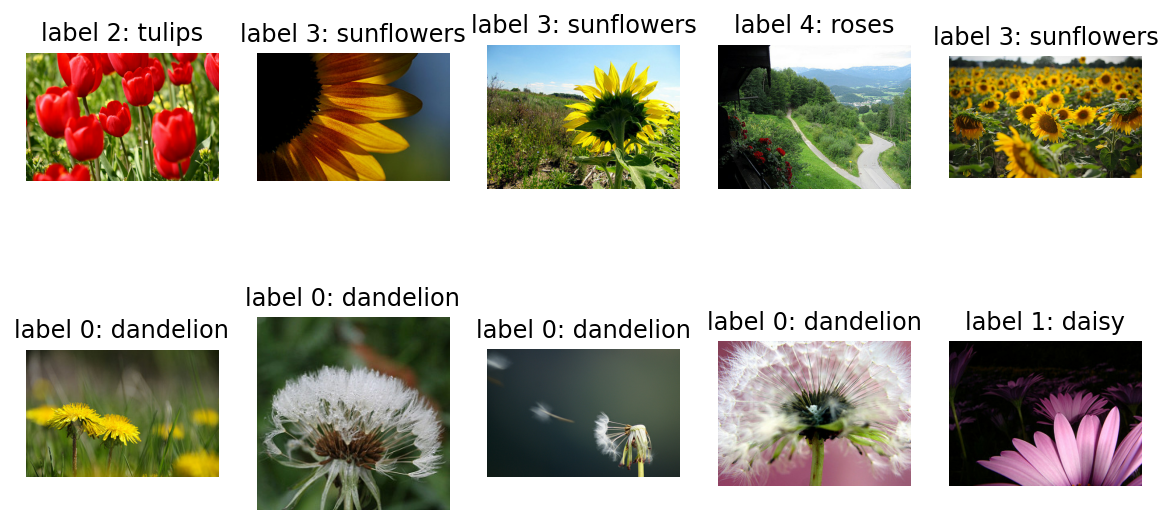

In [15]:
# 시각화
plt.figure(figsize=(10, 5))

get_label_name = metadata.features['label'].int2str

for idx, (image, label) in enumerate(raw_train.take(10)):  # 10개의 데이터를 가져 옵니다.
    plt.subplot(2, 5, idx+1)
    plt.imshow(image)
    plt.title(f'label {label}: {get_label_name(label)}')
    plt.axis('off')

In [87]:
# 타입캐스팅
IMG_SIZE = 160

def format_example(image, label):
    image = tf.cast(image, tf.float32) #image=float(image)같은 타입캐스팅의 텐서플로우 버전입니다.
    image = (image/127.5)-1 #픽셀값의 scale 수정
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

이미지의 픽셀값을 127.5 로 나누고 1을 빼주는 이유? 

0~255 사이의 값들을 그 중간값인 127.5로 나누고 1을 뺐으므로, -1 과 1 사이의 실수값이 된다.

In [17]:
# map 으로 이미지 사이즈를 통일해줍니다.
train = raw_train.map(format_example)
validation = raw_validation.map(format_example)
test = raw_test.map(format_example)

print(train)
print(validation)
print(test)

<MapDataset shapes: ((160, 160, 3), ()), types: (tf.float32, tf.int64)>
<MapDataset shapes: ((160, 160, 3), ()), types: (tf.float32, tf.int64)>
<MapDataset shapes: ((160, 160, 3), ()), types: (tf.float32, tf.int64)>


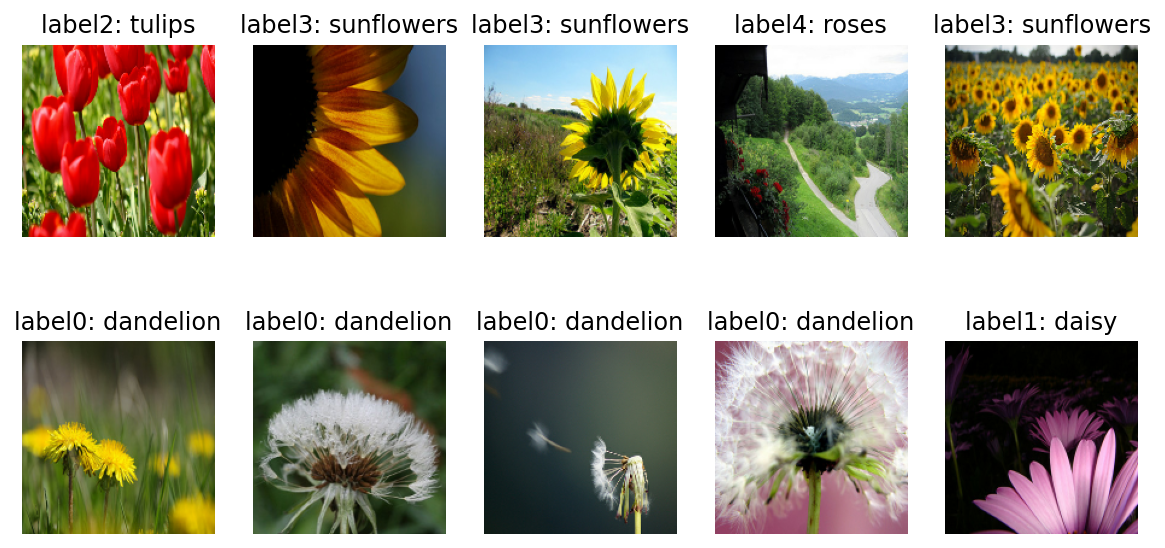

In [18]:
# 잘 리사이즈 되었는지 시각화
plt.figure(figsize=(10, 5))

get_label_name = metadata.features['label'].int2str

for idx, (image, label) in enumerate(train.take(10)):
    plt.subplot(2, 5, idx+1)
    image = (image + 1)/2
    plt.imshow(image)
    plt.title(f"label{label}: {get_label_name(label)}")
    plt.axis("off")

# Transfer Learning

## 전처리

In [19]:
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# VGG16 사전학습된 베이스 모델 설정
base_model = tf.keras.applications.VGG16(input_shape=IMG_SHAPE,
                                         include_top=False, # 가중치만 사용하고 컨볼루젼 블록 동결
                                         weights='imagenet')

58900480/58889256 [==============================] - 0s 0us/step


In [23]:
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

In [24]:
# 훈련 검증 테스트의 배치 설정
train_batches = train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
validation_batches = validation.batch(BATCH_SIZE)
test_batches = test.batch(BATCH_SIZE)

In [25]:
# 훈련 배치에서 하나만 꺼내 텐서 크기 확인
for image_batch, label_batch in train_batches.take(1):
    break
    
image_batch.shape, label_batch.shape

(TensorShape([32, 160, 160, 3]), TensorShape([32]))

In [26]:
# 베이스 모델에 들어갈 입력 텐서의 크기 확인
feature_batch = base_model(image_batch)
feature_batch.shape

TensorShape([32, 5, 5, 512])

In [40]:
print(feature_batch_average.shape)

(32, 512)


## 모델 정의 및 훈련

In [36]:
# VGG16 베이스 모델 구조
base_model.summary()

Model: "vgg16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 160, 160, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 160, 160, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 160, 160, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 80, 80, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 80, 80, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 80, 80, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 40, 40, 128)       0     

In [35]:
# VGG16 아래에 붙일 커스텀 분류기 모델 세팅
base_model.trainable = False

global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
dense_layer = tf.keras.layers.Dense(units=512, activation='relu')
prediction_layer = tf.keras.layers.Dense(units=5, activation= 'softmax')

model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,
  prediction_layer
])

In [36]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 5, 5, 512)         14714688  
_________________________________________________________________
global_average_pooling2d_6 ( (None, 512)               0         
_________________________________________________________________
dense_12 (Dense)             (None, 512)               262656    
_________________________________________________________________
dense_13 (Dense)             (None, 5)                 2565      
Total params: 14,979,909
Trainable params: 265,221
Non-trainable params: 14,714,688
_________________________________________________________________


In [38]:
learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])

In [42]:
EPOCHS = 20
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data = validation_batches)

Epoch 1/20
92/92 [==============================] - 8s 80ms/step - loss: 0.5106 - accuracy: 0.8392 - val_loss: 0.5508 - val_accuracy: 0.7956
Epoch 2/20
92/92 [==============================] - 8s 81ms/step - loss: 0.4957 - accuracy: 0.8474 - val_loss: 0.5452 - val_accuracy: 0.8038
Epoch 3/20
92/92 [==============================] - 8s 81ms/step - loss: 0.4827 - accuracy: 0.8460 - val_loss: 0.5192 - val_accuracy: 0.8174
Epoch 4/20
92/92 [==============================] - 8s 83ms/step - loss: 0.4683 - accuracy: 0.8505 - val_loss: 0.5177 - val_accuracy: 0.8147
Epoch 5/20
92/92 [==============================] - 8s 82ms/step - loss: 0.4544 - accuracy: 0.8532 - val_loss: 0.5067 - val_accuracy: 0.8120
Epoch 6/20
92/92 [==============================] - 8s 82ms/step - loss: 0.4451 - accuracy: 0.8583 - val_loss: 0.4947 - val_accuracy: 0.8202
Epoch 7/20
92/92 [==============================] - 8s 81ms/step - loss: 0.4342 - accuracy: 0.8600 - val_loss: 0.5036 - val_accuracy: 0.8147
Epoch 8/20
92

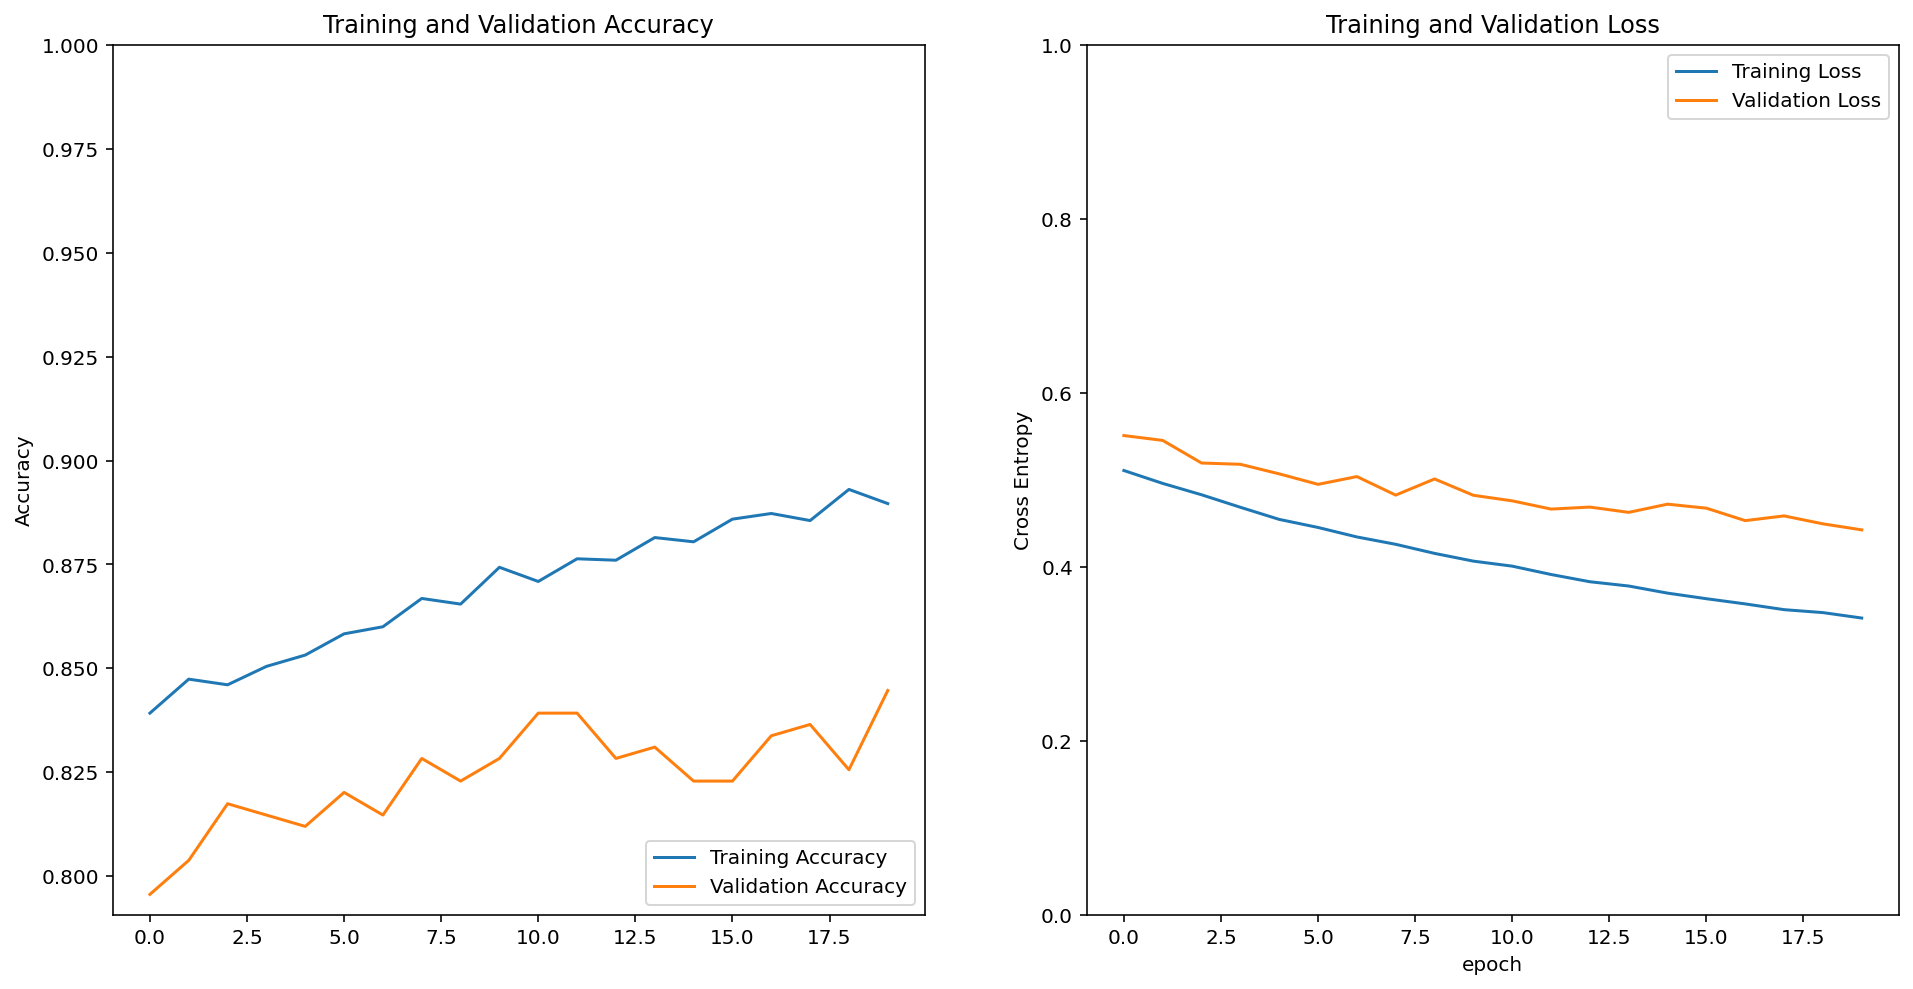

In [89]:
# 훈련 검증 시각화
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [44]:
for image_batch, label_batch in test_batches.take(1):
    images = image_batch
    labels = label_batch
    predictions = model.predict(image_batch)
    pass

predictions

array([[4.60677920e-03, 2.53844280e-02, 8.75421166e-01, 9.03328881e-03,
        8.55542794e-02],
       [9.99791205e-01, 1.81053270e-04, 1.05618415e-06, 2.85773558e-06,
        2.38801331e-05],
       [7.29089022e-01, 1.29710168e-01, 2.20953114e-02, 9.73579660e-02,
        2.17475332e-02],
       [3.86609143e-04, 1.51208998e-03, 5.81154227e-01, 9.36540950e-04,
        4.16010499e-01],
       [7.28103697e-01, 2.40353853e-01, 1.01359794e-02, 6.73701195e-03,
        1.46694565e-02],
       [9.53589976e-01, 3.32788453e-02, 2.34778807e-03, 1.00512393e-02,
        7.32084329e-04],
       [2.67915265e-03, 2.83592637e-03, 9.56237972e-01, 1.63380355e-02,
        2.19089091e-02],
       [3.80245417e-01, 5.94520926e-01, 3.23214452e-04, 2.38011479e-02,
        1.10935245e-03],
       [3.01633589e-03, 3.91059730e-04, 2.30827257e-02, 9.04413044e-01,
        6.90968260e-02],
       [9.99632955e-01, 3.52743664e-04, 6.74566877e-07, 1.17549262e-05,
        1.91449885e-06],
       [9.72513855e-01, 2.4962

In [45]:
predictions = np.argmax(predictions, axis=1)
predictions

array([2, 0, 0, 2, 0, 0, 2, 1, 3, 0, 0, 3, 3, 4, 0, 3, 2, 0, 2, 4, 2, 0,
       1, 0, 1, 3, 2, 4, 4, 3, 0, 4])

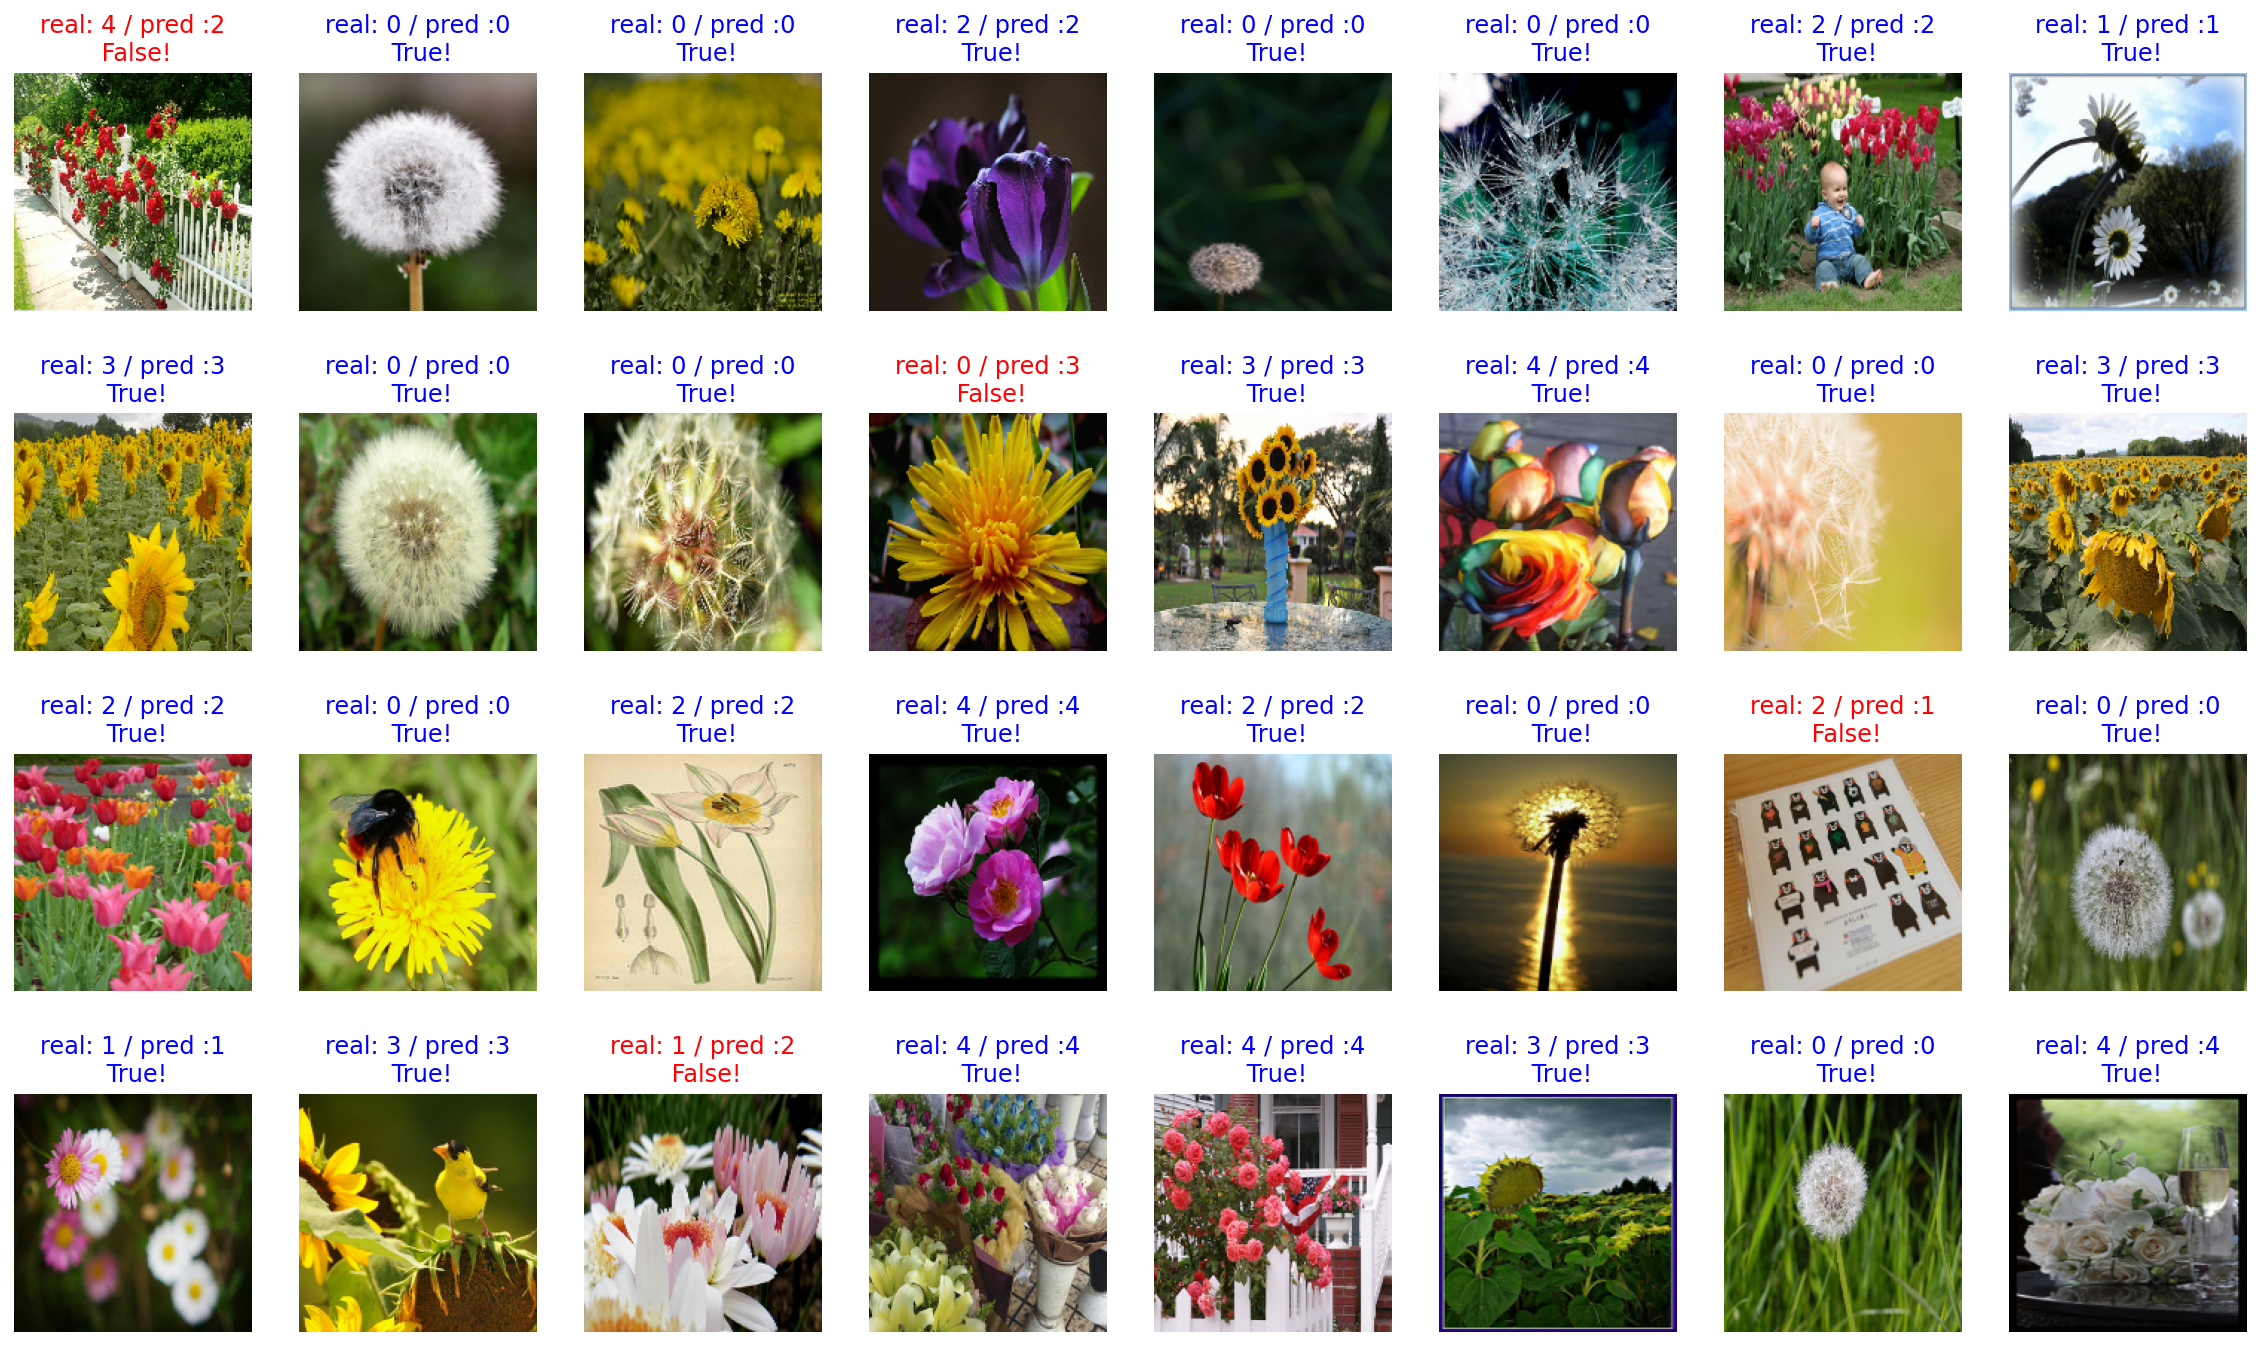

In [46]:
# 이미지 시각화를 통해 정답과 오답 이미지 비교
plt.figure(figsize=(20, 12))

for idx, (image, label, prediction) in enumerate(zip(images, labels, predictions)):
    plt.subplot(4, 8, idx+1)
    image = (image + 1) / 2
    plt.imshow(image)
    correct = label == prediction
    title = f'real: {label} / pred :{prediction}\n {correct}!'
    if not correct:
        plt.title(title, fontdict={'color': 'red'})
    else:
        plt.title(title, fontdict={'color': 'blue'})
    plt.axis('off')

꽃잎의 갈라진 형태와 색상에서 이종 간의 유사성을 발견하고 헷갈려하는 것을 확인할 수 있다. 
dendelion / tulip, dendelion / sunflower

In [90]:
# 예측률 
count = 0
for image, label, prediction in zip(images, labels, predictions):
    correct = label == prediction
    if correct:
        count = count + 1

print(count / 32 * 100) # 약 95% 내외

87.5


### 모델 저장

In [48]:
!mkdir -p ~/aiffel/tf_flowers/checkpoint
!mkdir -p ~/aiffel/tf_flowers/images

In [50]:
import os
checkpoint_dir = os.getenv("HOME") + "/aiffel/tf_flowers/checkpoint"
checkpoint_file_path = os.path.join(checkpoint_dir, 'checkpoint')

if not os.path.exists('checkpoint_dir'):
    os.mkdir('checkpoint_dir')
    
model.save_weights(checkpoint_file_path)     # checkpoint 파일 생성

if os.path.exists(checkpoint_file_path):
  print('checkpoint 파일 생성 OK!!')

checkpoint 파일 생성 OK!!


### 새로운 이미지로 예측하기

디버깅: 경로 설정시 실수로 중복된 디렉토리와 파일 삭제

In [59]:
!rm -rf ~/data/* ~/aiffel/tf_flowers/images/cats_vs_dogs
!rm -rf ~/data/* ~/aiffel/tf_flowers/images/cat_face.jpg
!rm -rf ~/data/* ~/aiffel/tf_flowers/images/my_dog.jpg
!rm -rf ~/data/* ~/aiffel/tf_flowers/images/my_cat.jpg

rm: cannot remove '/aiffel/data/cat_face.jpg': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/.ipynb_checkpoints': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/4.0.0/cats_vs_dogs-train.tfrecord-00004-of-00008': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/4.0.0/cats_vs_dogs-train.tfrecord-00002-of-00008': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/4.0.0/dataset_info.json': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/4.0.0/features.json': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/4.0.0/cats_vs_dogs-train.tfrecord-00006-of-00008': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/4.0.0/cats_vs_dogs-train.tfrecord-00001-of-00008': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/4.0.0/cats_vs_dogs-train.tfrecord-00003-of-00008': Read-only file system
rm: cannot remove '/aiffel/data/cats_vs_dogs/4.0.0/cats_vs_dogs-train.t

확인

In [52]:
!ln -s ~/data/* ~/aiffel/tf_flowers/images/

ln: failed to create symbolic link '/aiffel/aiffel/tf_flowers/images/cat_face.jpg': File exists
ln: failed to create symbolic link '/aiffel/aiffel/tf_flowers/images/cats_vs_dogs': File exists
ln: failed to create symbolic link '/aiffel/aiffel/tf_flowers/images/my_cat.jpg': File exists
ln: failed to create symbolic link '/aiffel/aiffel/tf_flowers/images/my_dog.jpg': File exists


이미지 경로 설정 

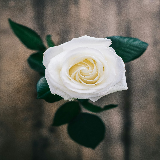

In [63]:
IMG_SIZE = 160
img_dir_path = os.getenv("HOME") + "/aiffel/tf_flowers/images"
roses_image_path = os.path.join(img_dir_path, 'roses/rose_1.jpg')

rose_image = load_img(roses_image_path, target_size=(IMG_SIZE, IMG_SIZE))
rose_image

In [64]:
rose_image = img_to_array(rose_image).reshape(1, IMG_SIZE, IMG_SIZE, 3)
rose_image.shape

(1, 160, 160, 3)

In [65]:
prediction = model.predict(rose_image)
prediction

array([[0., 0., 0., 0., 1.]], dtype=float32)

외부 이미지를 한장씩 불러와 추론해줄 재사용 함수 정의

In [71]:
def show_and_predict_image(dirpath, filename, img_size=160):
    filepath = os.path.join(dirpath, filename)
    image = load_img(filepath, target_size=(img_size, img_size))
    plt.imshow(image)
    plt.axis('off')
    image = img_to_array(image).reshape(1, img_size, img_size, 3)
    prediction = model.predict(image)[0]
    rose_percentage = round(prediction[4] * 100)
    sunflower_percentage = round(prediction[3] * 100)
    dendelion_percentage = round(prediction[0] * 100)
    print(f"This image seems {rose_percentage}% rose\n{sunflower_percentage}% sunflower,\nand {dendelion_percentage}% dendelion.")

This image seems 0% rose
100% sunflower,
and 0% dendelion.


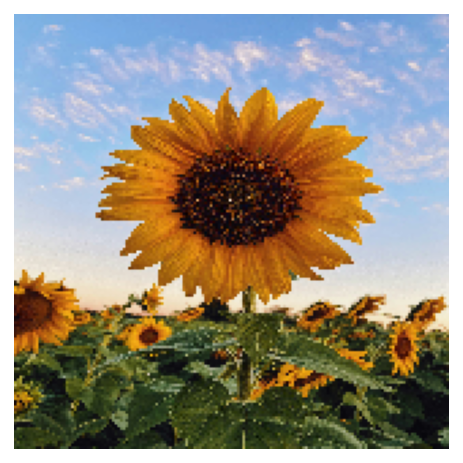

In [72]:
filename = 'sunflowers/sunflower_3.jpg'

show_and_predict_image(img_dir_path, filename)

This image seems 0% rose
0% sunflower,
and 100% dendelion.


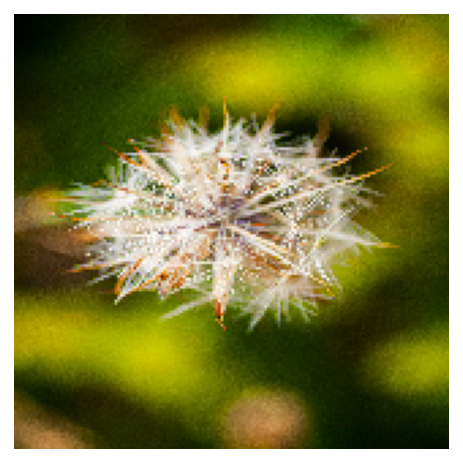

In [77]:
filename = 'dendelions/dendelion_3.jpg'

show_and_predict_image(img_dir_path, filename)

This image seems 100% rose
0% sunflower,
and 0% dendelion.


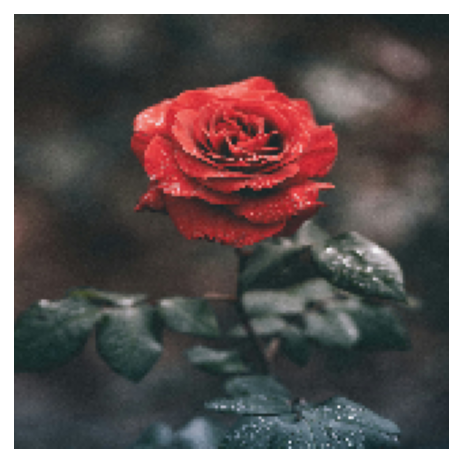

In [74]:
filename = "roses/rose_3.jpg"
show_and_predict_image(img_dir_path, filename)

-끝-